# Seguimiento de una consigna constante

*(Traducción a Python del livescript `seguir_consigna.mlx`, usando `numpy`, `scipy` y `control`)*

Vamos a emplear el método visto en clase para seguir una consigna constante. Recordad que este método tiene el problema de que necesita un modelo perfecto del sistema. Vamos a emplear nuestro sistema de ejemplos anteriores.

**Controlable y observable:**
$$A_c =\begin{pmatrix}1&2&0 \\ -2&3&0\\ 1&0&-2\end{pmatrix}, \quad B = \begin{pmatrix}1& 2\\ 1&0\\ 0&0\end{pmatrix}, \quad C_0 = (1\ 2\ 1)$$

In [1]:
import numpy as np
import control as ct
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

In [2]:
Ac = np.array([[1, 2, 0], [-2, 3, 0], [1, 0, -2]])
B  = np.array([[1, 2], [1, 0], [0, 0]])
Co = np.array([[1, 2, 1]])

## Caso 1: más entradas que salidas (2 entradas, 1 salida)

Vamos a suponer en primer lugar que el sistema admite realimentación directa de estados; esto es lo mismo que suponer que tenemos una salida $y=I_{n\times n}x$ (supuesto que los estados son directamente observables).

Podemos calcular una ganancia para estabilizar el sistema mediante cualquiera de los métodos descritos en controlabilidad; aquí vamos a emplear directamente `control.place`.

In [3]:
lam = [-3, -4, -5]   # posicion deseada de los polos
K = ct.place(Ac, B, lam)
K

array([[-1.9977,  7.    ,  0.0045],
       [ 4.4989, -2.4998,  1.4977]])

Para que sea posible llevar el sistema a valores arbitrarios necesitamos poder construir una ganancia $F = (C(BK-A)^{-1}B)^{-1}$. En nuestro caso, la matriz $F^{-1}=C_{1\times3}(BK-A)^{-1}_{3\times3}B_{3\times2}$ **no es invertible** (no es cuadrada); de hecho, solo podrá serlo si coincide el número de entradas con el de salidas.

Si $BK-A$ es invertible, podemos todavía intentar un "apaño":

$$Bu^* =(BK- A)x_d \Rightarrow Cx_d = C(BK-A)^{-1}Bu^*$$
$$y_{d\,(m\times1)} = \big(C(BK-A)^{-1}B\big)_{m\times k}\,u^*_{k\times 1}$$

Si $k>m$ (más entradas que salidas), podemos ajustar las entradas de modo que obtengamos la salida deseada; si $k<m$ lo más probable es que no podamos hacer nada. En nuestro caso, tenemos dos entradas y una salida: podemos dar a una un valor arbitrario (por ejemplo 0) y calcular cuánto debe valer la otra en función de $y_d$.

Construimos una función que lo haga para nuestro caso (ver `u_estrella` al final del notebook — **ojo:** esta función concreta solo sirve para sistemas con dos entradas y una salida, tal y como advierte también el `.mlx` original).

In [4]:
def u_estrella(C, A, B, K, yd):
    """
    Calcula la entrada 'u*' de compensacion necesaria para que la salida
    en estado estacionario alcance yd. Solo sirve para sistemas con dos
    entradas y una salida: fija la primera entrada a 0 y despeja la
    segunda en funcion de yd.
    """
    aux = C @ np.linalg.inv(B @ K - A) @ B   # si A no es invertible, se acabo la fiesta
    return np.array([0, yd / aux[0, 1]])

Podemos ahora montar nuestro sistema realimentado, con un valor de salida $y_d=12$.

In [5]:
yd = 12
ustr = u_estrella(Co, Ac, B, K, yd)
ustr

array([ 0.    , 30.0452])

Creamos una función específica para llevar a cabo la integral (solución del sistema); ver `sistema_lineal_cs` al final del notebook.

In [6]:
def sistema_lineal_cs(t, x, K, ustr, A, B):
    """Sistema lineal realimentado, con compensacion 'ustr' para seguir consigna."""
    u = -K @ x
    return A @ x + B @ (u + ustr)

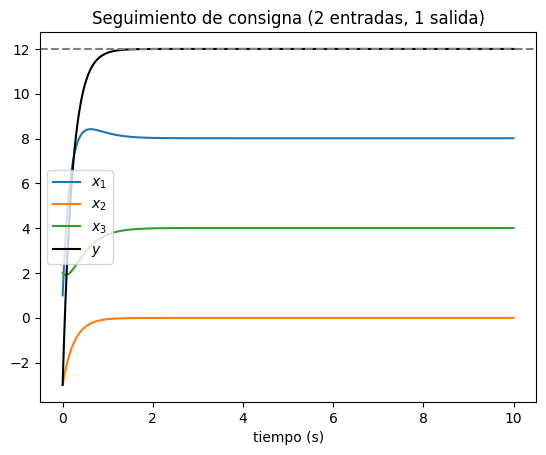

In [7]:
tf = 10
x0 = [1, -3, 2]

sol = solve_ivp(sistema_lineal_cs, [0, tf], x0, args=(K, ustr, Ac, B), max_step=1e-2)

plt.figure(1)
plt.plot(sol.t, sol.y.T, label=[r'$x_1$', r'$x_2$', r'$x_3$'])
plt.plot(sol.t, (Co @ sol.y).T, 'k', label='$y$')
plt.axhline(yd, color='gray', linestyle='--')
plt.xlabel('tiempo (s)')
plt.title('Seguimiento de consigna (2 entradas, 1 salida)')
plt.legend()
plt.show()

La salida converge correctamente al valor deseado $y_d=12$.

## Caso 2: mismo número de entradas y salidas (2 entradas, 2 salidas)

Podemos reconstruir el ejemplo para ver el caso en que coinciden el número de entradas y salidas, y se puede calcular $F=(C(BK-A)^{-1}B)^{-1}$ de verdad (sin necesitar el "apaño" anterior).

Mantenemos los valores de $A$ y $B$ y construimos una nueva $C=\begin{pmatrix}1&0&0 \\ 0&1&0\end{pmatrix}$, es decir, consideramos que se pueden medir directamente los dos primeros estados. Calculamos $F$,

In [8]:
C = np.array([[1, 0, 0], [0, 1, 0]])
F = np.linalg.inv(C @ np.linalg.inv(B @ K - Ac) @ B)
F

array([[ 0.0045,  4.    ],
       [ 3.7477, -1.9998]])

Elegimos unos valores de entrada que la salida debe seguir,

In [9]:
def sistema_lineal_F(t, x, yd, K, F, A, B):
    """Sistema lineal realimentado, con precompensacion F para seguir consigna yd."""
    u = -K @ x + F @ yd
    return A @ x + B @ u

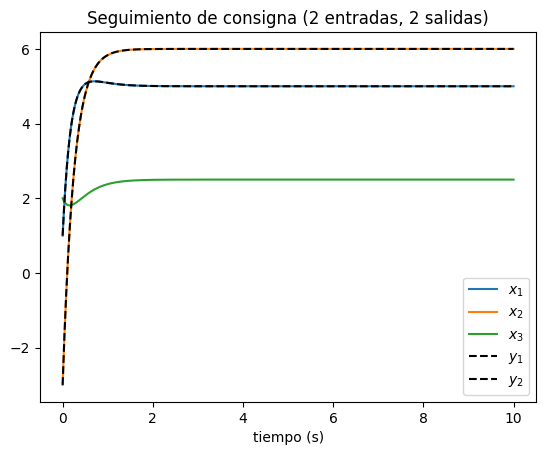

In [10]:
yd = np.array([5, 6])
tf = 10
x0 = [1, -3, 2]

sol = solve_ivp(sistema_lineal_F, [0, tf], x0, args=(yd, K, F, Ac, B), max_step=1e-2)

plt.figure(2)
plt.plot(sol.t, sol.y.T, label=[r'$x_1$', r'$x_2$', r'$x_3$'])
plt.plot(sol.t, (C @ sol.y).T, 'k--', label=['$y_1$', '$y_2$'])
plt.xlabel('tiempo (s)')
plt.title('Seguimiento de consigna (2 entradas, 2 salidas)')
plt.legend()
plt.show()

Ambas salidas convergen a los valores deseados $y_d=(5,6)$, ahora sin necesidad de ningún "apaño": con el mismo número de entradas que de salidas, $F$ es directamente invertible.